#Human Evaluation of AI Responses to Data Science Questions
**Ruth Chane**

*Data Science Final Project*

5/16/2026

**Introduction**

This project was completed as the final project for my Data Science course.I wanted to design and collect my own data in order to better understand the challenges of real-world data collection and human-centered AI evaluation.

Artificial intelligence tools are becoming increasingly common in education, programming, and technical work. However, evaluating AI-generated responses is difficult because people may judge responses differently based on clarity, helpfulness, detail, and structure rather than technical correctness alone.

For this project, I designed and distributed surveys where participants evaluated AI-generated responses to data science-related questions. The goal was to explore patterns in how humans perceive AI-generated explanations and to gain experience designing an original data collection and evaluation process.

#Data Collection and Survey Design

The dataset for this project was collected through Google Forms surveys distributed to students and community members on campus. Participants came from a variety of academic backgrounds, including both technical and non-technical disciplines.

The survey evaluated multiple AI-generated responses to data science-related questions. Participants compared and rated responses without being informed which AI system generated each response.

I created four separate survey versions in order to vary the placement and ordering of AI-generated responses. This was done to reduce potential response-order bias and create a more balanced evaluation process.

Each participant rated AI-generated responses on a Likert scale from 1 to 5 across multiple evaluation categories:

**Clarity**

**Completeness**

**Helpfulness**

**Overall Quality**

A total of 19 completed survey responses were collected across the four survey versions. Survey Versions 1 and 2 each received 4 responses, Version 3 received 5 responses, and Version 4 received 6 responses.

One intended evaluation metric related to correctness was inconsistently captured during the Google Forms export process and was therefore excluded from the final quantitative analysis.

#Importing and Combining the Data
Since the project used four different survey versions, the responses first needed to be exported and combined into a single dataset for analysis.

In [69]:
import pandas as pd

# Load datasets
v1 = pd.read_csv("/content/version1_p1ab_p2ab.csv - Form Responses 1.csv")
v2 = pd.read_csv("/content/version2_p1ba_p2ab.csv - Form Responses 1.csv")
v3 = pd.read_csv("/content/version3_p1ab_p2ba.csv - Form Responses 1.csv")
v4 = pd.read_csv("/content/version4_p1ba_p2ba.csv - Form Responses 1.csv")

# Add survey version labels
v1["survey_version"] = "V1_P1AB_P2AB"
v2["survey_version"] = "V2_P1BA_P2AB"
v3["survey_version"] = "V3_P1AB_P2BA"
v4["survey_version"] = "V4_P1BA_P2BA"

# Combine datasets
df = pd.concat([v1, v2, v3, v4], ignore_index=True)

# Show shape + first rows
print(df.shape)

df.head()

(19, 23)


,Column 1,"Response A\nOverfitting is what happens when a machine learning model learns the training data too well—including the noise and random quirks—rather than just the underlying patterns.\nA simple way to think about it:\nImagine a student memorizing answers to specific practice questions instead of understanding the subject.\nThey might score perfectly on that exact practice test, but struggle with new questions on the real exam.\nThat’s overfitting.\nWhat’s going on under the hood?\nA model is trying to find patterns that connect inputs (data) to outputs (answers). When it overfits, it builds a very complicated “rulebook” that matches the training data almost perfectly—but that rulebook doesn’t generalize well to new, unseen data.\nWhy is overfitting a problem?\nBecause in real life, we care about how the model performs on new data, not the data it already saw.\nAn overfit model:\nHas very high accuracy on training data\nBut poor accuracy on new (test) data\nSo even though it looks good during training, it fails when actually used.\nQuick example\nSuppose you're predicting house prices:\nA good model learns general trends (bigger houses cost more, location matters).\nAn overfit model might memorize that “the blue house on Elm Street sold for $350,000” and treat that as a rule—something that doesn’t help predict other houses.\nThe core issue\nOverfitting = memorization instead of understanding\nWhy it happens\nModel is too complex for the amount of data\nNot enough training data\nTraining for too long\nData is noisy\nBottom line\nOverfitting is a problem because it creates models that look smart during training but make poor predictions in the real world—where it actually matters.",How clear is this response?,How complete is this response?,How helpful is this response?,Overall quality of this response,"Response B\nOverfitting is a common challenge in machine learning where a model learns the training data too well, including its noise and details, to the extent that it negatively impacts the model's performance on new data.\nTo understand it in simple terms, imagine a student preparing for a history exam.\nGood Learning: The student understands the historical concepts and can answer both the practice questions and new questions on the exam.\nOverfitting: The student simply memorizes the exact practice test questions and answers word-for-word. When the actual exam has slightly different questions, the student fails because they didn't learn the underlying concepts.\nWhy Overfitting is a Problem\nWhen a model overfits, it loses its ability to generalize. Here is why this becomes a major issue in real-world applications:\nPoor Performance on New Data: The primary goal of machine learning is to make accurate predictions on unseen data. An overfitted model will perform beautifully on the training data but fail miserably in the real world.\nHigh Sensitivity to Noise: The model treats random variations or errors in the training data as important rules. If there is incorrect data, the model memorizes the mistake.\nLack of Flexibility: Overly complex models become rigid. They cannot adapt when presented with slight variations in user behavior, market trends, or input data.\nCommon Causes of Overfitting\nModel Complexity: The model has too many parameters (like a deep neural network or a high-degree polynomial) relative to the amount of data available.\nSmall Training Data: The dataset is not large or diverse enough to cover all possible scenarios.\nTraining for Too Long: The model is allowed to run through the training data for too many epochs, allowing it to memorize rather than learn.\nHow to Prevent It\nTo ensure a model learns the underlying trend rather than just memorizing the data, data scientists use several techniques:\nSimplify the Model: Use simpler algorithms or reduce the number of parameters.\nGet More Data: Feeding the model more varied data helps it distinguish noise from genuine patterns.\nRegularization: Add a

#Cleaning and Preparing the Dataset

Before beginning the analysis, the combined survey dataset needed to be cleaned and standardized. Since the responses came from four separate Google Forms exports, the columns first had to be renamed into a consistent and readable format for analysis.

The dataset was also checked for missing values, data types, and unnecessary columns before conducting any statistical analysis or visualization.

In [70]:
# Check current column names

df.columns

Index(['Column 1',
       ' Response A\nOverfitting is what happens when a machine learning model learns the training data too well—including the noise and random quirks—rather than just the underlying patterns.\nA simple way to think about it:\nImagine a student memorizing answers to specific practice questions instead of understanding the subject.\nThey might score perfectly on that exact practice test, but struggle with new questions on the real exam.\nThat’s overfitting.\nWhat’s going on under the hood?\nA model is trying to find patterns that connect inputs (data) to outputs (answers). When it overfits, it builds a very complicated “rulebook” that matches the training data almost perfectly—but that rulebook doesn’t generalize well to new, unseen data.\nWhy is overfitting a problem?\nBecause in real life, we care about how the model performs on new data, not the data it already saw.\nAn overfit model:\nHas very high accuracy on training data\nBut poor accuracy on new (test) data\nS

In [71]:
# Rename columns into cleaner labels

df.columns = [
    "timestamp_start",

    "responseA_prompt1",
    "clarity_A1",
    "completeness_A1",
    "helpfulness_A1",
    "overall_A1",

    "responseB_prompt1",
    "clarity_B1",
    "completeness_B1",
    "helpfulness_B1",
    "overall_B1",

    "responseA_prompt2",
    "clarity_A2",
    "completeness_A2",
    "helpfulness_A2",
    "overall_A2",

    "responseB_prompt2",
    "clarity_B2",
    "completeness_B2",
    "helpfulness_B2",
    "overall_B2",

    "survey_version",
    "timestamp_end"
]

df.head()

,timestamp_start,responseA_prompt1,clarity_A1,completeness_A1,helpfulness_A1,overall_A1,responseB_prompt1,clarity_B1,completeness_B1,helpfulness_B1,...,completeness_A2,helpfulness_A2,overall_A2,responseB_prompt2,clarity_B2,completeness_B2,helpfulness_B2,overall_B2,survey_version,timestamp_end
0,5/1/2026 11:41:36,1,3,3.0,2,2,2,2,5,5,...,2,4,3,2,2,2,5,5,V1_P1AB_P2AB,NaN
1,5/5/2026 15:18:49,4,2,4.0,2,4,4,4,5,4,...,5,4,5,3,4,3,3,3,V1_P1AB_P2AB,NaN
2,5/5/2026 17:24:08,5,4,4.0,4,4,5,4,5,5,...,3,4,3,4,5,4,4,4,V1_P1AB_P2AB,NaN
3,5/5/2026 19:12:22,5,4,NaN,4,3,5,5,5,4,...,3,4,4,5,4,5,5,5,V1_P1AB_P2AB,NaN
4,NaN,4,1,5.0,2,1,3,4,4,3,...,4,4,3,5,4,5,4,4,V2_P1BA_P2AB,5/6/2026 14:55:35


In [72]:
# Combine timestamps into one column

df["timestamp"] = df["timestamp_start"].combine_first(df["timestamp_end"])

# Remove old timestamp columns

df = df.drop(columns=["timestamp_start", "timestamp_end"])

# Check result

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   responseA_prompt1  19 non-null     int64  
 1   clarity_A1         19 non-null     int64  
 2   completeness_A1    18 non-null     float64
 3   helpfulness_A1     19 non-null     int64  
 4   overall_A1         19 non-null     int64  
 5   responseB_prompt1  19 non-null     int64  
 6   clarity_B1         19 non-null     int64  
 7   completeness_B1    19 non-null     int64  
 8   helpfulness_B1     19 non-null     int64  
 9   overall_B1         19 non-null     int64  
 10  responseA_prompt2  19 non-null     int64  
 11  clarity_A2         19 non-null     int64  
 12  completeness_A2    19 non-null     int64  
 13  helpfulness_A2     19 non-null     int64  
 14  overall_A2         19 non-null     int64  
 15  responseB_prompt2  19 non-null     int64  
 16  clarity_B2         19 non-nu

In [73]:
# Check missing values

df.isnull().sum()

,0
responseA_prompt1,0
clarity_A1,0
completeness_A1,1
helpfulness_A1,0
overall_A1,0
responseB_prompt1,0
clarity_B1,0
completeness_B1,0
helpfulness_B1,0
overall_B1,0


The dataset was checked for missing values after the columns were cleaned and standardized. Most rating columns contained complete responses, but one evaluation field (completeness_A1) contained a single missing value because a participant skipped that question in the survey.

Since only one response was missing and the dataset was small, the missing value was left as NaN rather than being filled or removed.

#Understanding the Dataset Structure
Before beginning analysis, the dataset structure and data types were inspected to confirm that the survey ratings were stored correctly for statistical analysis. Most columns were numerical rating variables using integer values from 1 to 5, while the survey version and timestamp columns were stored as text-based object variables.

The inspection also confirmed that the dataset contained 19 survey responses and 22 total columns after cleaning and standardization.

In [74]:
# Display dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   responseA_prompt1  19 non-null     int64  
 1   clarity_A1         19 non-null     int64  
 2   completeness_A1    18 non-null     float64
 3   helpfulness_A1     19 non-null     int64  
 4   overall_A1         19 non-null     int64  
 5   responseB_prompt1  19 non-null     int64  
 6   clarity_B1         19 non-null     int64  
 7   completeness_B1    19 non-null     int64  
 8   helpfulness_B1     19 non-null     int64  
 9   overall_B1         19 non-null     int64  
 10  responseA_prompt2  19 non-null     int64  
 11  clarity_A2         19 non-null     int64  
 12  completeness_A2    19 non-null     int64  
 13  helpfulness_A2     19 non-null     int64  
 14  overall_A2         19 non-null     int64  
 15  responseB_prompt2  19 non-null     int64  
 16  clarity_B2         19 non-nu

#Descriptive Statistics and Initial Analysis
After cleaning and organizing the dataset, descriptive statistics were used to better understand participant ratings across the evaluation categories. Since the survey used 1-5 Likert scales, calculating averages and summary statistics helped identify overall trends in how participants evaluated the AI-generated responses.

The analysis focused on comparing ratings for clarity, completeness, helpfulness, and overall quality across the different AI responses.

In [75]:
# Summary statistics for numerical columns

df.describe()

,responseA_prompt1,clarity_A1,completeness_A1,helpfulness_A1,overall_A1,responseB_prompt1,clarity_B1,completeness_B1,helpfulness_B1,overall_B1,responseA_prompt2,clarity_A2,completeness_A2,helpfulness_A2,overall_A2,responseB_prompt2,clarity_B2,completeness_B2,helpfulness_B2,overall_B2
count,19.000000,19.000000,18.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,3.894737,3.631579,4.000000,3.736842,3.736842,4.000000,3.842105,3.684211,3.789474,3.947368,3.894737,3.789474,3.631579,3.947368,3.894737,3.789474,3.842105,3.736842,4.052632,3.947368
std,0.994135,1.065130,0.685994,1.045738,1.045738,1.105542,0.958190,1.376494,0.976328,1.025978,0.737468,0.917663,1.116071,0.779864,0.809303,1.134262,0.834210,0.991189,0.705036,0.779864
min,1.000000,1.000000,3.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,3.000000,1.000000,2.000000,2.000000,3.000000,3.000000
25%,3.500000,3.000000,4.000000,3.000000,3.000000,4.000000,3.000000,2.500000,3.000000,3.500000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,4.500000,4.000000,4.000000,4.500000,4.000000,5.000000,4.500000,5.000000,4.500000,5.000000,4.000000,4.500000,4.500000,4.000000,4.500000,5.000000,4.000000,4.500000,4.500000,4.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


#Research Question

The main research questions for this analysis were:

Which AI-generated responses received the highest overall ratings?

Were some evaluation categories rated more consistently than others?

Did Response A or Response B tend to receive higher ratings across clarity, completeness, helpfulness, and overall quality?

How much variation existed in participant evaluations across different prompts?


**Comparing Average Ratings Across Responses**

To better understand how participants evaluated the AI-generated responses, average ratings were calculated for each response category. This made it possible to compare overall trends across clarity, completeness, helpfulness, and overall quality.

In [76]:
# Calculate average ratings for each response set

average_scores = {

    "A1 Overall": df["overall_A1"].mean(),
    "B1 Overall": df["overall_B1"].mean(),

    "A2 Overall": df["overall_A2"].mean(),
    "B2 Overall": df["overall_B2"].mean(),

    "A1 Helpfulness": df["helpfulness_A1"].mean(),
    "B1 Helpfulness": df["helpfulness_B1"].mean(),

    "A2 Helpfulness": df["helpfulness_A2"].mean(),
    "B2 Helpfulness": df["helpfulness_B2"].mean()

}

average_scores

{'A1 Overall': np.float64(3.736842105263158),
 'B1 Overall': np.float64(3.9473684210526314),
 'A2 Overall': np.float64(3.8947368421052633),
 'B2 Overall': np.float64(3.9473684210526314),
 'A1 Helpfulness': np.float64(3.736842105263158),
 'B1 Helpfulness': np.float64(3.789473684210526),
 'A2 Helpfulness': np.float64(3.9473684210526314),
 'B2 Helpfulness': np.float64(4.052631578947368)}

The average ratings showed that most AI-generated responses received relatively positive evaluations, with scores generally ranging between 3.7 and 4.1 out of 5.

Among the evaluated categories, the B2 response received the highest helpfulness rating, with an average score slightly above 4.0. In contrast, the A1 response tended to receive the lowest ratings across both overall quality and helpfulness.

The results suggest that participants were generally able to distinguish differences in perceived quality between responses, even though most ratings remained within the upper-middle range of the scale.

One interesting pattern was that helpfulness ratings often appeared slightly higher than overall quality ratings. This may suggest that participants valued practical usefulness even when responses were not viewed as perfect overall.

#Visualizing Average Ratings
To better compare participant evaluations across responses, a bar chart was created showing the average ratings for overall quality and helpfulness. Visualizing the averages makes differences between responses easier to identify than viewing raw numerical outputs alone.

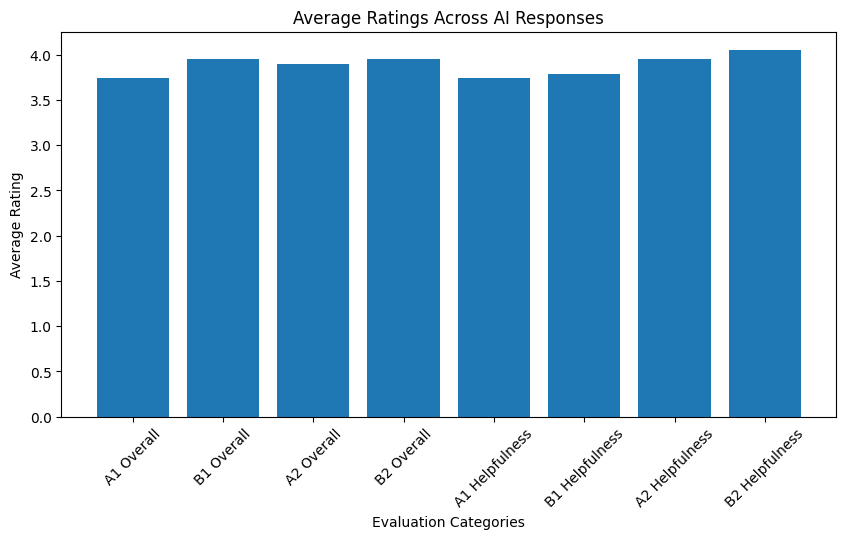

In [77]:
import matplotlib.pyplot as plt

# Data for visualization

labels = list(average_scores.keys())
values = list(average_scores.values())

# Create bar chart

plt.figure(figsize=(10,5))
plt.bar(labels, values)

# Labels and title

plt.title("Average Ratings Across AI Responses")
plt.xlabel("Evaluation Categories")
plt.ylabel("Average Rating")

# Rotate labels

plt.xticks(rotation=45)

plt.show()

**Analyzing Rating Variability and Consistency**

While average ratings help summarize overall trends, they do not show how consistent participant opinions were. To better understand variation in human evaluations, the standard deviation of each rating category was examined.

A lower standard deviation indicates that participants generally agreed on a rating, while a higher standard deviation suggests more disagreement or variability in participant perceptions.

In [78]:
# Calculate standard deviations for rating columns

std_values = {

    "A1 Overall": df["overall_A1"].std(),
    "B1 Overall": df["overall_B1"].std(),

    "A2 Overall": df["overall_A2"].std(),
    "B2 Overall": df["overall_B2"].std(),

    "A1 Helpfulness": df["helpfulness_A1"].std(),
    "B1 Helpfulness": df["helpfulness_B1"].std(),

    "A2 Helpfulness": df["helpfulness_A2"].std(),
    "B2 Helpfulness": df["helpfulness_B2"].std()

}

std_values

{'A1 Overall': 1.0457376590053493,
 'B1 Overall': 1.0259783520851542,
 'A2 Overall': 0.8093026382225121,
 'B2 Overall': 0.7798635358208024,
 'A1 Helpfulness': 1.0457376590053493,
 'B1 Helpfulness': 0.976328005472037,
 'A2 Helpfulness': 0.7798635358208024,
 'B2 Helpfulness': 0.7050361858740393}


The results showed that several of the B responses had slightly lower standard deviation values than the A responses. For example, B2 Helpfulness had one of the lowest variability scores, suggesting participants were relatively consistent in rating that response as helpful.

In contrast, A1 Overall and A1 Helpfulness showed higher variability, meaning participant opinions about those responses were more mixed.

Overall, the relatively moderate standard deviation values across the dataset suggest that participant ratings were somewhat consistent, while still showing expecteed differences in individual perception.

# Visualizing the Results
To better understand participant evaluation patterns, visualizations were created to compare average ratings across the different AI-generated responses.

These charts make it easier to identify trends in participant preferences across categories such as clarity, completeness, helpfulness, and overall quality.

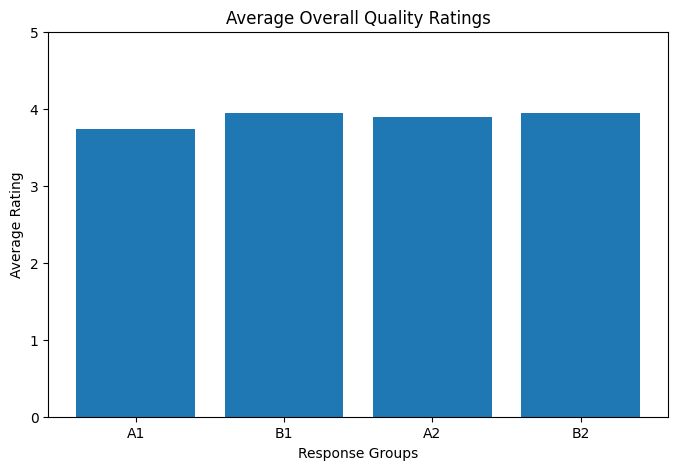

In [79]:

# Average scores for overall quality
overall_scores = {
    "A1": df["overall_A1"].mean(),
    "B1": df["overall_B1"].mean(),
    "A2": df["overall_A2"].mean(),
    "B2": df["overall_B2"].mean()
}

# Create bar chart
plt.figure(figsize=(8,5))

plt.bar(overall_scores.keys(), overall_scores.values())

plt.title("Average Overall Quality Ratings")
plt.xlabel("Response Groups")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.show()

##Interpretation of Overall Quality Ratings

This chart answers the first research question: which AI-generated responses received the highest overall ratings?

The overall quality scores were fairly close across all four response groups, with averages mostly between 3.7 and 4.0 out of 5. This suggests that participants generally viewed the AI-generated responses as useful and reasonably strong.

However, the B responses received slightly higher overall ratings than the A responses for both prompts. B1 and B2 were both rated a little higher than A1 and A2, suggesting that participants may have preferred the response style used in the B responses.

Because the differences are small and the sample size is limited, I would not treat this as a definitive ranking. Instead, I interpret it as an exploratory pattern: participants seemed to slightly favor the B responses in overall quality.

## What This Shows So Far

This first analysis shows that the survey responses were not random. Participants gave generally positive ratings, but they still showed some preference differences between response groups. The next step is to look beyond overall quality and compare the specific evaluation categories: clarity, completeness, and helpfulness.

# Comparing Evaluation Categories

While overall quality provides a broad summary of participant opinions, it is also important to compare the individual evaluation categories separately.
Comparing these categories helps identify whether certain response groups performed better in specific areas rather than only in overall perception.

To better visualize these differences, the average ratings for each category were grouped and compared across the four response groups.

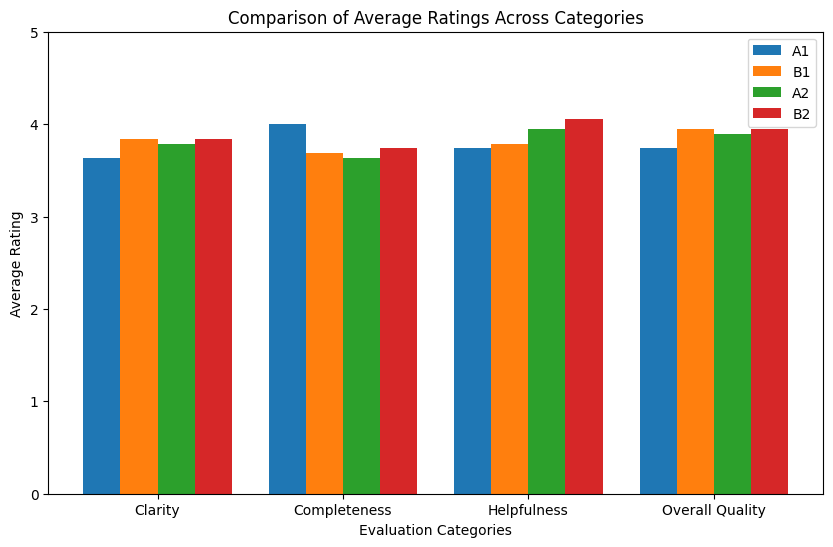

In [80]:
# Create grouped averages for each category

categories = ["Clarity", "Completeness", "Helpfulness", "Overall Quality"]

A1_scores = [
    df["clarity_A1"].mean(),
    df["completeness_A1"].mean(),
    df["helpfulness_A1"].mean(),
    df["overall_A1"].mean()
]

B1_scores = [
    df["clarity_B1"].mean(),
    df["completeness_B1"].mean(),
    df["helpfulness_B1"].mean(),
    df["overall_B1"].mean()
]

A2_scores = [
    df["clarity_A2"].mean(),
    df["completeness_A2"].mean(),
    df["helpfulness_A2"].mean(),
    df["overall_A2"].mean()
]

B2_scores = [
    df["clarity_B2"].mean(),
    df["completeness_B2"].mean(),
    df["helpfulness_B2"].mean(),
    df["overall_B2"].mean()
]

import numpy as np

x = np.arange(len(categories))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, A1_scores, width, label="A1")
plt.bar(x - 0.5*width, B1_scores, width, label="B1")
plt.bar(x + 0.5*width, A2_scores, width, label="A2")
plt.bar(x + 1.5*width, B2_scores, width, label="B2")

plt.xticks(x, categories)

plt.ylabel("Average Rating")
plt.xlabel("Evaluation Categories")

plt.title("Comparison of Average Ratings Across Categories")

plt.ylim(0,5)

plt.legend()

plt.show()


This visualization provides a clearer comparison of how participants rated the AI-generated responses across the four evaluation categories.

Several patterns can be observed from the chart:

- The B responses generally received slightly higher ratings than the A responses across most categories.
- B2 received the highest ratings in helpfulness and overall quality, suggesting that participants consistently viewed that response as strong.
- A1 received the highest completeness rating, indicating that participants may have viewed that response as more detailed or thorough even though its overall ratings were slightly lower.
- The ratings across all categories remained relatively close, with most averages falling between 3.5 and 4.1 out of 5.

Overall, the results suggest that participants generally rated all AI-generated responses positively, while still showing small but noticeable differences in perceived quality and usefulness between response groups.


## Comparing Response Consistency

In addition to comparing average ratings, it is also important to examine how consistent participant ratings were across the different response groups.

While averages show overall trends, variability measurements help determine whether participants generally agreed or disagreed in their evaluations.

# Visualizing Rating Consistency

To better understand participant agreement across the response groups, standard deviation values were visualized for each evaluation category.

Lower standard deviation values indicate that participants rated a response more consistently, while higher values suggest greater disagreement or variation in participant opinions.

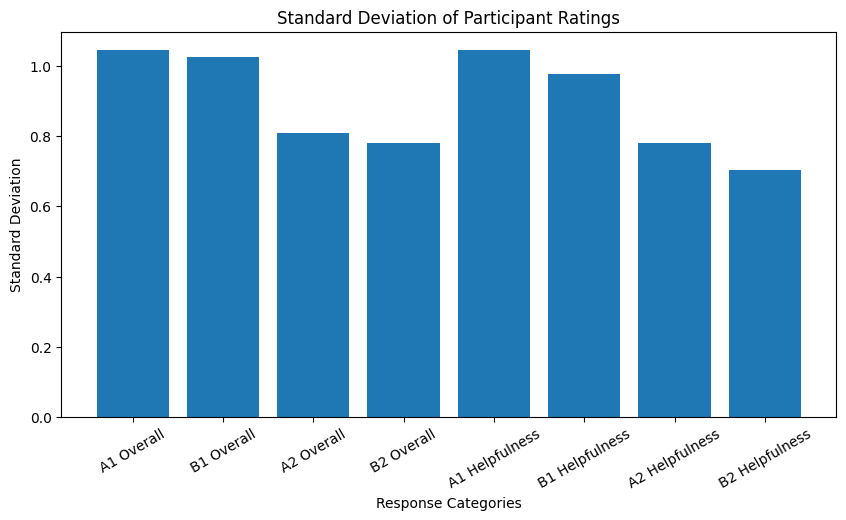

In [81]:
# Standard deviation comparison chart

std_categories = [
    "A1 Overall",
    "B1 Overall",
    "A2 Overall",
    "B2 Overall",
    "A1 Helpfulness",
    "B1 Helpfulness",
    "A2 Helpfulness",
    "B2 Helpfulness"
]

std_scores = [
    df["overall_A1"].std(),
    df["overall_B1"].std(),
    df["overall_A2"].std(),
    df["overall_B2"].std(),
    df["helpfulness_A1"].std(),
    df["helpfulness_B1"].std(),
    df["helpfulness_A2"].std(),
    df["helpfulness_B2"].std()
]

plt.figure(figsize=(10,5))

plt.bar(std_categories, std_scores)

plt.title("Standard Deviation of Participant Ratings")
plt.xlabel("Response Categories")
plt.ylabel("Standard Deviation")

plt.xticks(rotation=30)

plt.show()

## Interpretation of Rating Consistency

This visualization helps answer the research question about consistency in participant evaluations.

Several response groups showed relatively low standard deviation values, suggesting that participants generally agreed in their ratings. In particular, B2 Helpfulness had one of the lowest variability scores, indicating stronger agreement among participants about the usefulness of that response.

In contrast, A1 Overall and A1 Helpfulness showed higher variability, suggesting that participant opinions about those responses were more mixed.

Overall, the standard deviation values were not extremely high, which suggests that participant ratings were reasonably consistent across the survey despite natural differences in personal interpretation and evaluation style.

# Comparing Prompt Performance

The survey included two different prompt styles in order to examine whether participant evaluations changed depending on the type of AI-generated explanation being assessed.

- Prompt 1 focused on a conceptual machine learning explanation:
  “Explain what overfitting is in machine learning in simple terms and why it can be a problem.”

- Prompt 2 focused on an applied data-cleaning scenario:
  “Imagine you are working with a dataset that has missing values and inconsistent or messy labels. What steps would you take to clean the data before using it?”

Participants evaluated anonymous Response A and Response B answers for each prompt without being told which AI model generated them.

To investigate whether prompt type influenced participant perceptions, average ratings for Prompt 1 and Prompt 2 were compared across the evaluation categories.

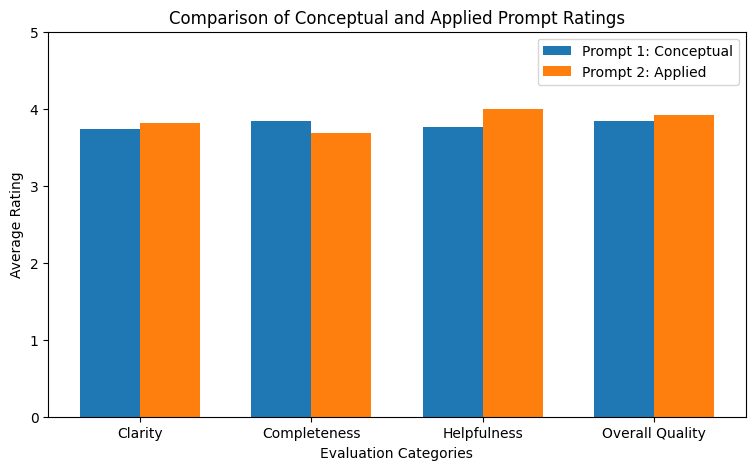

In [82]:
# Compare Prompt 1 vs Prompt 2 averages

prompt1_scores = {
    "Clarity": (df["clarity_A1"].mean() + df["clarity_B1"].mean()) / 2,
    "Completeness": (df["completeness_A1"].mean() + df["completeness_B1"].mean()) / 2,
    "Helpfulness": (df["helpfulness_A1"].mean() + df["helpfulness_B1"].mean()) / 2,
    "Overall Quality": (df["overall_A1"].mean() + df["overall_B1"].mean()) / 2
}

prompt2_scores = {
    "Clarity": (df["clarity_A2"].mean() + df["clarity_B2"].mean()) / 2,
    "Completeness": (df["completeness_A2"].mean() + df["completeness_B2"].mean()) / 2,
    "Helpfulness": (df["helpfulness_A2"].mean() + df["helpfulness_B2"].mean()) / 2,
    "Overall Quality": (df["overall_A2"].mean() + df["overall_B2"].mean()) / 2
}

categories = list(prompt1_scores.keys())

prompt1_values = list(prompt1_scores.values())
prompt2_values = list(prompt2_scores.values())

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, prompt1_values, width, label="Prompt 1: Conceptual")
plt.bar(x + width/2, prompt2_values, width, label="Prompt 2: Applied")

plt.xticks(x, categories)

plt.ylabel("Average Rating")
plt.xlabel("Evaluation Categories")

plt.title("Comparison of Conceptual and Applied Prompt Ratings")

plt.ylim(0,5)

plt.legend()
plt.savefig('/content/model_comparison.png', bbox_inches='tight')
plt.show()


## Comparing ChatGPT and Gemini Responses

For this project:

- Response A was generated using ChatGPT
- Response B was generated using Gemini

Participants were not told which AI model produced each response during the survey process. This was done to reduce bias and encourage participants to evaluate the responses based only on quality and usefulness rather than brand recognition.

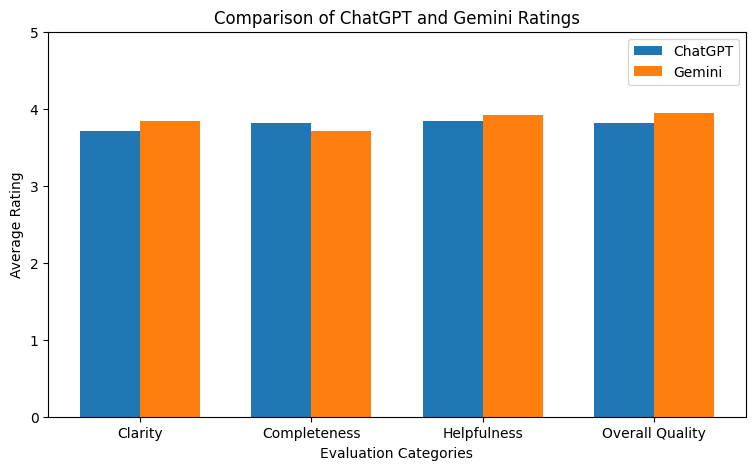

In [62]:
# Compare ChatGPT vs Gemini averages

chatgpt_scores = {
    "Clarity": (df["clarity_A1"].mean() + df["clarity_A2"].mean()) / 2,
    "Completeness": (df["completeness_A1"].mean() + df["completeness_A2"].mean()) / 2,
    "Helpfulness": (df["helpfulness_A1"].mean() + df["helpfulness_A2"].mean()) / 2,
    "Overall Quality": (df["overall_A1"].mean() + df["overall_A2"].mean()) / 2
}

gemini_scores = {
    "Clarity": (df["clarity_B1"].mean() + df["clarity_B2"].mean()) / 2,
    "Completeness": (df["completeness_B1"].mean() + df["completeness_B2"].mean()) / 2,
    "Helpfulness": (df["helpfulness_B1"].mean() + df["helpfulness_B2"].mean()) / 2,
    "Overall Quality": (df["overall_B1"].mean() + df["overall_B2"].mean()) / 2
}

categories = list(chatgpt_scores.keys())

chatgpt_values = list(chatgpt_scores.values())
gemini_values = list(gemini_scores.values())

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, chatgpt_values, width, label="ChatGPT")
plt.bar(x + width/2, gemini_values, width, label="Gemini")

plt.xticks(x, categories)

plt.ylabel("Average Rating")
plt.xlabel("Evaluation Categories")

plt.title("Comparison of ChatGPT and Gemini Ratings")

plt.ylim(0,5)

plt.legend()

plt.show()

This visualization compares the average participant ratings for ChatGPT and Gemini across the four evaluation categories.

Overall, both AI systems received relatively similar ratings, with most averages falling between approximately 3.7 and 4.0 out of 5. However, Gemini responses tended to receive slightly higher ratings in clarity, helpfulness, and overall quality.

ChatGPT responses received slightly higher completeness ratings overall. This may suggest that participants viewed some ChatGPT responses as more detailed or explanatory, particularly for the conceptual overfitting prompt.

The differences between the models were relatively small, which suggests that both AI systems performed similarly across the prompts included in this study. However, the analysis still demonstrates how human-centered evaluation methods can reveal subtle differences in participant perception of AI-generated responses.

Because the dataset consisted of only 19 survey responses and two prompts, these findings should be interpreted as exploratory rather than definitive conclusions about model performance.

# Conclusions and Final Insights

This project explored how people evaluate AI-generated responses across multiple dimensions including clarity, completeness, helpfulness, and overall quality.

Using survey-based human evaluations, the analysis compared responses generated by ChatGPT and Gemini across both conceptual and applied data science prompts.

Several important patterns emerged throughout the analysis.

Overall, participant ratings for both AI systems were generally positive, with most average scores falling between approximately 3.7 and 4.0 out of 5. While the differences between the systems were relatively small, Gemini responses tended to receive slightly higher ratings in clarity, helpfulness, and overall quality across several evaluation categories.

ChatGPT responses occasionally received slightly higher completeness ratings, particularly on the conceptual machine learning prompt. This may suggest that participants perceived some ChatGPT explanations as more detailed or thorough.

The analysis also showed that applied, real-world prompts tended to receive slightly stronger ratings in usefulness and overall quality compared to conceptual prompts. Additionally, the standard deviation analysis revealed differences in participant agreement, suggesting that some responses were viewed more consistently than others.

Although the dataset was relatively small, the project demonstrates how human-centered evaluation methods can provide insight into how users perceive AI-generated explanations beyond simple technical accuracy alone.

Overall, this project highlights the growing importance of evaluating AI systems not only based on correctness, but also based on communication quality, usability, and human perception.

# Limitations

Several limitations should be considered when interpreting the results of this project.

First, the dataset was relatively small, consisting of only 19 completed survey responses. Because of this, the findings should be viewed as exploratory rather than statistically definitive.

Second, participant backgrounds varied across technical and non-technical disciplines. Different levels of familiarity with machine learning and data science concepts may have influenced how responses were evaluated.

Another limitation was that one intended evaluation metric related to correctness was inconsistently captured during the Google Forms export process and therefore could not be fully included in the quantitative analysis.

Additionally, the study only evaluated two prompts and two AI systems. A larger-scale study including more prompts, additional participants, and more AI models would likely produce stronger and more generalizable findings.

Finally, because the project focused on human perception, higher ratings do not necessarily guarantee factuality. Participants may respond differently based on writing style, structure,or explanation length rather than purely technical correctness.

# Future Improvements

Several future improvements could strengthen this project and expand the analysis further.

Possible improvements include:

- Collecting a larger number of survey responses
- Including additional AI systems beyond ChatGPT and Gemini(e.g Claude)
- Expanding the number and variety of prompts
- Separating technical and non-technical participant groups for comparison
- Incorporating statistical significance testing
- Adding written participant feedback alongside numerical ratings
- Building interactive dashboards for visualization and exploration

Future versions of this project could also explore how factors such as tone, formatting,response length, or explanation style influence human trust and perception of AI-generated responses.


# New Techniques Learned
One new technique I explored during this project was designing and analyzing a human-evaluation dataset collected through survey methodology rather than using a pre-existing dataset.

I also learned how to combine multiple exported survey datasets, standardize inconsistent columns, calculate variability using standard deviation analysis, and build grouped comparison visualizations using Matplotlib.

In addition, I practiced structuring a data science project as a narrative analysis rather than simply presenting isolated charts or summary statistics.

# Final Reflection
Through this project, I learned how much work goes into building and analyzing a real dataset from start to finish as I wanted to try something different by designing my own survey process, collecting responses, combining multiple datasets, cleaning inconsistent exports, and organizing the data into a format suitable for analysis.

One of the main reasons I chose this topic was because I have become increasingly interested in how people perceive AI-generated responses and interact with AI systems more generally. I wanted to explore that relationship on a smaller scale while also gaining experience conducting my own human-centered data collection process.

One of the most interesting parts of the project was seeing how participant evaluations were influenced not just by the information itself, but also by factors such as clarity, helpfulness, structure, tone, and explanation style. Even when responses covered similar ideas, participants still showed noticeable preferences in how they rated them.

This project also helped me better understand how important data cleaning and preprocessing are in real-world data science workflows. Even with a relatively small dataset, I ran into several challenges during the process. For example, one survey question was accidentally not marked as required, which resulted in a missing value in the dataset. I also experienced issues during the Google Forms export process where one intended evaluation question was not preserved correctly across the combined datasets. Working through these problems gave me a much better understanding of how messy real-world data collection can become and how important careful organization is before analysis can even begin.

In addition, I gained more experience using Python, Pandas, and Matplotlib to perform exploratory data analysis, calculate descriptive statistics, compare groups, and create visualizations that communicate findings clearly. I also enjoyed learning how to structure the project as a narrative rather than simply producing charts and statistics.

Overall, this project gave me a much deeper understanding of the full data science process, from designing research questions and collecting original data to cleaning datasets, interpreting results, and communicating insights through storytelling and visualization(an important skill I aspire to be good at!).

# References
- OpenAI ChatGPT
- Google Gemini
- Python
- Pandas Documentation
- Matplotlib Documentation
- Google Forms
- Course materials and lecture notes from Data Science coursework